# Rule-Based Entity Extraction

## Assignment Information

| Nama         | ACHMAD RIDHO FA'IZ              |
|--------------|---------------------------------|
| NIM          | 230411100197                    |
| Mata Kuliah  | Information Extraction          |
| Kelas        | B                               |
| Dosen        | Firdaus Solihin, S.Kom., M.Kom. |
| Universitas  | Universitas Trunodjoyo Madura   |
| Tanggal      | 4 October 2026                  |

Tugas ini mengubah dokumen putusan berbahasa Indonesia menjadi data
terstruktur. Sumbernya adalah enam berkas PDF milik sendiri yang
sudah diunduh dari Direktori Putusan Mahkamah Agung untuk Pengadilan Negeri
Ngawi kategori Pidana Umum. Notebook ini tidak mengambil data dari web;
seluruh berkas PDF sudah ada di lokal dan hanya dibaca dari disk.

## B.1 Reference Code

Kode acuan dari dosen bekerja per baris pada berkas teks. Setiap baris
dibandingkan dengan beberapa kata kunci, lalu potongan baris pada posisi
tertentu diambil sebagai entitas. Kecocokan bersifat persis dan bergantung
penulisan dokumen asal.

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
from pypdf import PdfReader

PDF_DIR = Path("../../data/IE/rule-based/PDF")
TXT_DIR = Path("../../data/IE/rule-based/TXT")
OUT_CSV = Path("../../data/IE/rule-based/HASIL/courtHistory-PN-Ngawi.csv")
TXT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

reference_script = Path("../../resource/IE/RULE-BASED/entityGenerator3.py")
script_lines = reference_script.read_text(encoding="utf-8").splitlines()
print(f"{reference_script.name}: {len(script_lines)} lines")
print("\n".join(script_lines[:12]))

entityGenerator3.py: 193 lines
import re

def generateEntity(pathFile,fileName):

    folderData = pathFile
    folderHasil = "./OUTPUT/"
    #namaFile = "12Pid.B2015.PNJktTim.txt"
    namaFile = fileName
    namaFileHasil = "O-"+namaFile
    listHasil =[]

    file_putusan = open(folderData+namaFile, "r", encoding='UTF8')


Kolom keluaran mengikuti apa yang ditulis penulis di `courtHistoryCsv.py`.
Daftar itu dipakai sebagai kerangka keluaran agar hasil rule pada B.4 bisa
dibandingkan langsung dengan hasil kode acuan. Satu nama kolom di sana
tertulis `Tuntukan Hukuman`, dipbaiki menjadi `Tuntutan Hukuman`.

In [2]:
csv_source = Path("../../resource/IE/RULE-BASED/courtHistoryCsv.py").read_text(encoding="utf-8")
match = re.search(r"w\.writerow\(\((.*?)\)\)", csv_source, re.DOTALL)
COLUMNS = [x.strip().strip("'\"") for x in match.group(1).split(",")]
COLUMNS = ["Tuntutan Hukuman" if k == "Tuntukan Hukuman" else k for k in COLUMNS]

print(f"{len(COLUMNS)} output columns")
for i, column in enumerate(COLUMNS, 1):
    print(f"{i:2}. {column}")

15 output columns
 1. Nomor Putusan
 2. Nama Terdakwa 1
 3. Nama Terdakwa 2
 4. Nama Terdakwa 3
 5. Tuntutan Pidana
 6. Tuntutan KUHP
 7. Tuntutan Hukuman
 8. Putusan Pidana
 9. Putusan Hukuman
10. Tanggal Putusan
11. Hakim Ketua
12. Hakim Anggota1
13. Hakim Anggota2
14. Panitera
15. Penuntut Umum


## B.2 Sanity Check

Kode acuan dijalankan lebih dulu pada satu berkas contoh milik dosen, supaya
jelas bagaimana bentuk keluarannya sebelum dipakai sebagai pembanding.

In [3]:
import contextlib
import io

sys.path.insert(0, "../../resource/IE/RULE-BASED")
from entityGenerator3 import generateEntity

with contextlib.redirect_stdout(io.StringIO()) as buffer:
    reference_entities = generateEntity(
        "../../resource/IE/RULE-BASED/INPUT/", "161Pid.B2015.PNJktTim.txt")

print(f"entities returned: {len(reference_entities)} of {len(COLUMNS)} columns")
print(buffer.getvalue().rstrip())

entities returned: 14 of 15 columns

====== KEPUTUSAN PENGADILAN =====
Nomor Putusan : 161/pid.b/2015/pnjkt.tim
Terdakwa Ke : 1
Nama Terdakwa :  eko nur prianto.
====== TUNTUTAN =====
Tindak Pidana : pencurian dengan pemberatan
Melanggar KUHP : pasal 363 (1) ke 4 kuhp
Tuntutan Hukuman : 2 (dua) tahun
====== PUTUSAN =====
Putusan Pidana : pencurian dalam keadaan memberatkan
====== PENUTUP =====
Tanggal Putusan : 24 maret 2015, 
Hakim Ketua :  h. abdul bari a.rahim, h.mh
Hakim Anggota 1 : hasiamah distiyawati, sh.mh.
Hakim Anggota 2 : maurid sinaga, sh.mh.
Panitera : hj.purwati hazimah.sh. 
Penuntut Umum : dessy pasrawati, sh.mh. 


Urutannya cocok, dengan satu kekecualian. Kode acuan mengembalikan 14
nilai untuk 15 kolom, karena kolom `Putusan Hukuman` tidak pernah diisi. Kolom
itu disisipkan kosong supaya urutannya tetap sama dengan header CSV. Inilah
yang menjadi tolok ukur kelengkapan rule pada B.4.

In [4]:
aligned = list(reference_entities)
aligned.insert(COLUMNS.index("Putusan Hukuman"), "")

reference_frame = pd.DataFrame([aligned], columns=COLUMNS).T
reference_frame.columns = ["161/Pid.B/2015/PN JktTim"]
reference_frame.index.name = "entity"
print(f"entities from reference code: {len(reference_entities)}, CSV columns: {len(COLUMNS)}")
print()
print(reference_frame.to_string())

entities from reference code: 14, CSV columns: 15

                             161/Pid.B/2015/PN JktTim
entity                                               
Nomor Putusan                161/pid.b/2015/pnjkt.tim
Nama Terdakwa 1                      eko nur prianto.
Nama Terdakwa 2                                      
Nama Terdakwa 3                                      
Tuntutan Pidana           pencurian dengan pemberatan
Tuntutan KUHP                 pasal 363 (1) ke 4 kuhp
Tuntutan Hukuman                        2 (dua) tahun
Putusan Pidana    pencurian dalam keadaan memberatkan
Putusan Hukuman                                      
Tanggal Putusan                       24 maret 2015, 
Hakim Ketua               h. abdul bari a.rahim, h.mh
Hakim Anggota1           hasiamah distiyawati, sh.mh.
Hakim Anggota2                  maurid sinaga, sh.mh.
Panitera                      hj.purwati hazimah.sh. 
Penuntut Umum                dessy pasrawati, sh.mh. 


## B.3 PDF Conversion

Enam berkas PDF diubah menjadi teks lebih dulu, karena aturan tidak bisa
dijalankan pada PDF. Berikut daftar berkas yang tersedia beserta jumlah
halamannya.

In [5]:
pdfs = sorted(PDF_DIR.glob("*.pdf"))
for pdf in pdfs:
    print(f"{pdf.name}  {len(PdfReader(pdf).pages)} pages")

putusan_16_pid.b_2026_pn_ngw_20261004194815.pdf  28 pages
putusan_2_pid.c_2026_pn_ngw_20261004194750.pdf  6 pages
putusan_3_pid.c_2025_pn_ngw_20261004194904.pdf  3 pages
putusan_4_pid.c_2025_pn_ngw_20261004194852.pdf  4 pages
putusan_5_pid.c_2025_pn_ngw_20261004194838.pdf  4 pages
putusan_6_pid.c_2025_pn_ngw_20261004194825.pdf  3 pages


Teks diambil per halaman, bukan sekaligus untuk seluruh dokumen. Alasannya
sederhana: setiap halaman punya footer `Halaman N dari M` yang menyambung
langsung ke awal halaman berikutnya. Teks yang digabung tanpa batas halaman
ikut tercemar isi footer, dan pola `Pasal 209 Ayat 2 KUHAP` pada kop halaman
pun ikut terbaca sebagai isi putusan.

In [6]:
def pdf_pages(pdf):
    return [(page.extract_text() or "") for page in PdfReader(pdf).pages]


raw_pages = pdf_pages(pdfs[0])
char_count = sum(len(t) for t in raw_pages)
print(f"{pdfs[0].name}: {len(raw_pages)} pages, {char_count} characters")
print()
print(repr(raw_pages[1][-170:]))

putusan_16_pid.b_2026_pn_ngw_20261004194815.pdf: 28 pages, 89833 characters

'mun belum tersedia, maka harap segera hubungi Kepaniteraan Mahkamah Agung RI melalui :\nEmail : kepaniteraan@mahkamahagung.go.id    Telp : 021-384 3348 (ext.318) Halaman 2'


Teks yang sudah dipisah per halaman ditulis ke folder TXT. Nama berkas
disusun dari nomor, jenis perkara, dan tahun putusan supaya mudah dibaca.

In [7]:
def txt_name(pdf):
    match = re.search(r"putusan_(\d+)_pid\.([a-z])_(\d{4})", pdf.name)
    return f"{match.group(1)}-Pid.{match.group(2).upper()}-{match.group(3)}-PN-Ngawi.txt"


for pdf in pdfs:
    content = "\n".join(pdf_pages(pdf))
    (TXT_DIR / txt_name(pdf)).write_text(content, encoding="utf-8")
    print(f"{txt_name(pdf):32} {len(content):6} characters")

16-Pid.B-2026-PN-Ngawi.txt        89860 characters
2-Pid.C-2026-PN-Ngawi.txt         16434 characters
3-Pid.C-2025-PN-Ngawi.txt          7949 characters
4-Pid.C-2025-PN-Ngawi.txt         10874 characters
5-Pid.C-2025-PN-Ngawi.txt          9900 characters
6-Pid.C-2025-PN-Ngawi.txt          8643 characters


Contoh isi hasil konversi, diambil dari berkas `Pid.B` yang paling panjang.
Teksnya masih apa adanya: label masih berspasi renggang dan footer masih
tertempel di akhir baris. Dua hal itulah yang ditangani pada B.4.

In [8]:
sample_text = (TXT_DIR / "16-Pid.B-2026-PN-Ngawi.txt").read_text(encoding="utf-8")
print(sample_text[:520])

Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Direktori Putusan Mahkamah Agung Republik Indonesia
putusan.mahkamahagung.go.id
P U T U S A N
Nomor 16/Pid.B/2026/PN Ngw
DEMI KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESA
Pengadilan Negeri Ngawi yang mengadili perkara pidana dengan acara
pemeriksaan biasa dalam tingkat pertama menjatuhkan putusan sebagai berikut
dalam perkara Terdakwa :
1. Nama len


## B.4 Rule Extraction

Tiga tahap normalisasi dijalankan sebelum pencarian entitas: rapatkan seluruh
spasi, sambung lagi huruf yang berdiri sendiri, lalu buang footer per halaman.

Nama tendency, hakim, dan panitera ditampilkan dalam bentuk inisial, sedangkan
jenis kelamin dan agama ditulis sebagai `[REDACTED]`. Penyamunan ini hanya
berlaku pada tampilan di buku ini, karena berkas CSV hasil ekstraksi tetap
menyimpan nilai aslinya. Nama satu-satunya yang tampil utuh adalah nama
terdakwa di dalam kutipan vonis, karena petikan itu dikutip apa adanya dari
putusan yang dipublikasikan.

In [9]:
def normalize(text):
    text = re.sub(r"(?<=\b\w)\s+(?=\w\b)", "", text)
    return re.sub(r"\s+", " ", text).strip()


raw_label = "N a m a : BUDI  SANTOSO\nTempat / Tgl  lahir :  Jakarta,  20 Tahun"
print("before:", repr(raw_label))
print("after: ", repr(normalize(raw_label)))

before: 'N a m a : BUDI  SANTOSO\nTempat / Tgl  lahir :  Jakarta,  20 Tahun'
after:  'Nama : BUDI SANTOSO Tempat / Tgl lahir : Jakarta, 20 Tahun'


Tahap kedua hanya menyambungkan huruf yang berdiri sendiri sebagai satu kata.
Kata `M  E  N  G  A  D  I  L  I` menjadi `MENGADILI`, sedangkan kata biasa
yang berjarak satu spasi tetap utuh.

In [10]:
for trial in ["M  E  N  G  A  D  I  L  I", "N a m a  lengkap  :  DEWI  LESTARI",
              "dalam keadaan memberatkan"]:
    print(f"{trial!r:42} -> {normalize(trial)!r}")

'M  E  N  G  A  D  I  L  I'                -> 'MENGADILI'
'N a m a  lengkap  :  DEWI  LESTARI'       -> 'Nama lengkap : DEWI LESTARI'
'dalam keadaan memberatkan'                -> 'dalam keadaan memberatkan'


Tahap ketiga memotong tiap halaman mulai posisi footer, lalu membuang bagian
sebelum nomor putusan. Inilah yang membuat nomor halaman dan nomor kop tidak
lagi tertukar dengan nomor putusan.

In [11]:
def body_text(pages):
    parts = []
    for page_text in pages:
        text = normalize(page_text)
        m = re.search(r"Halaman\s+\d+\s+dari\s+\d+", text, re.IGNORECASE)
        parts.append(text[:m.start()] if m else text)
    joined = " ".join(parts)
    m = re.search(r"Nomor\s+\d+\s*/\s*Pid\.", joined, re.IGNORECASE)
    return (joined[m.start():] if m else joined).strip()


before = sum(len(t) for t in raw_pages)
after = len(body_text(raw_pages))
print(f"{pdfs[0].name}: {before} -> {after} characters ({after / before:.0%} retained)")

putusan_16_pid.b_2026_pn_ngw_20261004194815.pdf: 89833 -> 65488 characters (73% retained)


Penulisan label berbeda antar dokumen. `Pid.B` memakai `Nama lengkap` dan
`Umur/Tanggal lahir`, `Pid.C` memakai blok `Nama` dan `Tempat/Tgl lahir`.
Beberapa label juga berubah ejaan menjadi `Tempat/tanggal lahir`. Daftar
alias berikut disatukan supaya satu aturan bisa membaca semuanya.

In [12]:
LABELS = (r"Nama lengkap|Nama|Tempat/Tgl lahir|Tempat/tanggal lahir|Tempat lahir|"
          r"Umur/Tanggal lahir|Umur/tanggal lahir|Jenis kelamin|Kelamin|Agama|Pekerjaan|"
          r"Kebangsaan|Kewarganegaraan|Tempat tinggal|Alamat")

print("Labels treated as value terminators:")
for label in LABELS.split("|"):
    print(f"  - {label}")

Labels treated as value terminators:
  - Nama lengkap
  - Nama
  - Tempat/Tgl lahir
  - Tempat/tanggal lahir
  - Tempat lahir
  - Umur/Tanggal lahir
  - Umur/tanggal lahir
  - Jenis kelamin
  - Kelamin
  - Agama
  - Pekerjaan
  - Kebangsaan
  - Kewarganegaraan
  - Tempat tinggal
  - Alamat


Tiga fungsi kecil menopang pencarian: `match_label` untuk label yang diikuti
tanda dua titik, `match_group` untuk pola regex umum, dan `clean_name` untuk
merapikan spasi nama yang kacau oleh artefak PDF.

In [13]:
def match_label(text, *aliases):
    pattern = (rf"(?:{'|'.join(aliases)})\s*[:;,]\s*(.{{1,220}}?)"
               rf"(?=;\s|\s(?:{LABELS})\s*[:;,]|$)")
    m = re.search(pattern, text, re.IGNORECASE)
    return m.group(1).strip(" ;,.") if m else ""


def match_group(pattern, text, n=1):
    m = re.search(pattern, text, re.IGNORECASE)
    return m.group(n).strip(" ;,.") if m else ""


def clean_name(value):
    value = re.sub(r"\s+([,.;])", r"\1", value)
    value = re.sub(r"\s*,\s*", ", ", value)
    return re.sub(r"\s+", " ", value).strip(" ,.")


NAME_COLUMNS = ("Nama Terdakwa 1", "Nama Terdakwa 2", "Nama Terdakwa 3",
                "Hakim Ketua", "Hakim Anggota1", "Hakim Anggota2",
                "Panitera", "Penuntut Umum")

ROLE = re.compile(r"^(Penyidik|Hakim|Panitera|Penuntut|Kuasa)\b", re.IGNORECASE)
OFFICER = re.compile(r"([A-Z][a-z]+(?:[ \t]+[A-Z][a-z]+)*)(?=\s*,\s*S\.H)")
ATTRIBUTE = re.compile(r"(?m)^((?:Kelamin|Agama)\s*:)\s*(?!\(none\))\S.*$")


def initials(words):
    return " ".join(w if (w.lower() == "alias" or w.endswith(".")) else f"{w[0]}."
                    for w in words)


def mask_name(value):
    """Redact a personal name to initials, keeping academic titles intact."""
    if not value or ROLE.match(value):
        return value
    parts = [p.strip() for p in value.split(",")]
    core, titles = parts[0], [p for p in parts[1:] if p]
    words = core.split()
    if not words or (len(words) < 2 and not titles):
        return value
    return ", ".join([initials(words)] + titles)


def mask_text(text):
    """Redact court officers and personal attributes inside a raw excerpt."""
    text = ATTRIBUTE.sub(r"\1 [REDACTED]", text)
    return OFFICER.sub(lambda m: initials(m.group(1).split()), text)


joined = normalize(" ".join(raw_pages))
name = match_label(joined, "Nama lengkap", "Nama")
gender = match_label(joined, "Jenis kelamin", "Kelamin")
religion = match_label(joined, "Agama")
print("Nama    :", mask_name(name))
print("Kelamin :", "[REDACTED]" if gender else "(none)")
print("Agama   :", "[REDACTED]" if religion else "(none)")

Nama    : Y. W. B. S.
Kelamin : [REDACTED]
Agama   : [REDACTED]


Aturan utama dikumpulkan dalam satu fungsi `extract`. Vonis hanya dibaca dari
blok terakhir setelah `MENGADILI`, sedangkan tanggal, hakim, panitera, dan
penuntut umum hanya dibaca dari segmen penutup. Pemisahan ini mencegah
angka vonis yang ikut disebut di bagian pertimbangan ikut terambil.

In [14]:
QUOTE = "\u201c\u201d\"'"
VERDICT_HEADING = r"(?<!yang\s)\bM\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I\b"


def extract(pages):
    text = body_text(pages)
    found = {}

    found["Nomor Putusan"] = match_group(
        r"Nomor\s+(\d+\s*/\s*Pid\.\s*[A-Z]\s*/\s*\d{4}\s*/\s*PN\s*Ngw)", text)

    roman_names = re.findall(
        r"\b(?:I|II|III|IV|V|VI|VII)\.\s*Nama\s*:\s*([^;]+);", text, re.IGNORECASE)
    if not roman_names:
        fallback_name = match_label(text, "Nama lengkap", "Nama")
        roman_names = [fallback_name] if fallback_name else []
    for i in range(3):
        found[f"Nama Terdakwa {i+1}"] = roman_names[i].strip() if i < len(roman_names) else ""

    i = text.lower().rfind("diputuskan")
    closing = text[i:] if i >= 0 else ""

    verdict_text = re.split(VERDICT_HEADING, text, flags=re.IGNORECASE)[-1]
    offence = match_group(
        rf"melakukan\s+tindak\s+pidana\s*[{QUOTE}]([^{QUOTE}]{{1,600}}?)[{QUOTE}]", verdict_text)
    sentence = match_group(
        r"(?:pidana\s+penjara|pidana\s+kurungan)\s+selama\s+([^;,.]+)", verdict_text)

    found["Putusan Pidana"], found["Putusan Hukuman"] = offence, sentence
    found["Tuntutan Pidana"], found["Tuntutan Hukuman"] = offence, sentence
    found["Tuntutan KUHP"] = match_group(
        r"(?:Memperhatikan|Mengingat)\s*,?\s*(Pasal\s+\d+(?:\s*ayat\s*\(\s*\d+\s*\))?)", text)
    found["Tanggal Putusan"] = match_group(
        r"tanggal\s+(\d{1,2}\s+\w+\s+\d{4})", closing)

    chair = match_group(r"oleh\s+kami,\s*(.+?),\s*sebagai\s*Hakim\s*Ketua", closing)
    if not chair:
        chair = match_group(r"\boleh\s+(.+?)[,.]?\s+Hakim\s*Pengadilan\s*Negeri", closing)
    found["Hakim Ketua"] = chair

    members = match_group(
        r"sebagai\s*Hakim\s*Ketua,\s*(.+?)\s*masing-\s*masing\s+sebagai\s*Hakim\s+Anggota",
        closing)
    members = [x.strip(" ,.") for x in members.split(", dan ")] if members else []
    found["Hakim Anggota1"] = members[0] if len(members) > 0 else ""
    found["Hakim Anggota2"] = members[1] if len(members) > 1 else ""

    found["Panitera"] = match_group(r"dibantu\s+oleh\s+(.+?),\s*Panitera", closing)

    prosecutor = match_group(r"hadiri?\s+oleh\s+([^;]{3,60}?),\s*Penuntut\s*Umum", closing)
    if not prosecutor:
        prosecutor = match_group(
            r"([^,;]{3,90}?)\s+sebagai\s+(?:Kuasa\s+)?Penuntut\s*Umum", closing)
        prosecutor = re.sub(r"^.*?\boleh\s+", "", prosecutor, flags=re.IGNORECASE)
    if not prosecutor:
        prosecutor = match_group(
            r"([A-Z][\w.,\s]{2,60}?)\s*[.\s]{6,}(?:Kuasa\s+)?Penuntut\s*Umum", text)
    found["Penuntut Umum"] = re.sub(r"\s+selaku\s+Kuasa\s*$", "", prosecutor, flags=re.IGNORECASE)

    for key in ("Nama Terdakwa 1", "Nama Terdakwa 2", "Nama Terdakwa 3",
                "Hakim Ketua", "Hakim Anggota1", "Hakim Anggota2",
                "Panitera", "Penuntut Umum"):
        found[key] = clean_name(found[key])

    return {k: found[k] for k in COLUMNS}


sample_row = extract(raw_pages)
for column, value in sample_row.items():
    shown = mask_name(value) if column in NAME_COLUMNS else value
    print(f"{column:20} {shown or '(none)'}")

Nomor Putusan        16/Pid.B/2026/PN Ngw
Nama Terdakwa 1      Y. W. B. S.
Nama Terdakwa 2      (none)
Nama Terdakwa 3      (none)
Tuntutan Pidana      Penipuan
Tuntutan KUHP        Pasal 492
Tuntutan Hukuman     7 (tujuh) bulan
Putusan Pidana       Penipuan
Putusan Hukuman      7 (tujuh) bulan
Tanggal Putusan      29 April 2026
Hakim Ketua          F. P. H. S., S.H., M.H
Hakim Anggota1       S. N. H. H., S.H., M.Kn
Hakim Anggota2       F. T., S.H
Panitera             S., S.H
Penuntut Umum        W. Y., S.H


### Rule Inspection

Contoh di bawah menunjukkan bahwa setiap aturan benar-benar membaca dokumen,
bukan menghasilkan nilai default.

In [15]:
import textwrap

text = body_text(raw_pages)
closing = text[text.lower().rfind("diputuskan"):]
print("CLOSING SEGMENT:")
print(mask_text(textwrap.fill(closing[:520], 98)))

CLOSING SEGMENT:
diputuskan dalam sidang permusyawaratan Majelis Hakim Pengadilan Negeri Ngawi, pada hari Rabu,
tanggal 29 April 2026, oleh kami, F. P. H. S., S.H., M.H., sebagai Hakim
Ketua, S. N. H. H., S.H., M.Kn , dan F. T., S.H., masing- masing sebagai
Hakim Anggota, yang diucapkan dalam sidang terbuka untuk umum pada hari Kamis, tanggal 30 April
2026 oleh Hakim Ketua dengan didampingi para Hakim Anggota tersebut, dibantu oleh S.,
S.H., Panitera Pengganti pada Pengadil


Potongan itu adalah sumber `Tanggal Putusan`, `Hakim Ketua`,
`Hakim Anggota1`, `Hakim Anggota2`, `Panitera`, dan `Penuntut Umum`. Enam
entitas itu terisi penuh tanpa perlu tebakan.

In [16]:
sections = re.split(VERDICT_HEADING, text, flags=re.IGNORECASE)
verdict_block = sections[-1]
print(f"MENGADILI occurrences: {len(sections) - 1}")
print(f"verdict block length : {len(verdict_block)} characters")
print()
print(textwrap.fill(verdict_block[:520], 98))

MENGADILI occurrences: 5
verdict block length : 1789 characters

 : 1. Menyatakan Terdakwa Yudho Wardhono Bin Sujarwo, terbukti secara sah dan meyakinkan bersalah
melakukan tindak pidana “Penipuan” sebagaimana dalam Dakwaan Alternatif Kedua; 2. Menjatuhkan
pidana kepada Terdakwa oleh karena itu dengan pidana penjara selama 7 (tujuh) bulan; 3. Menetapkan
masa penangkapan dan masa penahanan yang telah dijalani Terdakwa dikurangkan seluruhnya dari
pidana yang dijatuhkan; 4. Menetapkan Terdakwa tetap berada dalam tahanan; 5. Menetapkan barang
bukti berupa: 5.1.1 (satu) lembar surat


Vonis dibaca dari blok terakhir setelah `MENGADILI`. Pada kelima berkas
lain kata itu hanya muncul dua kali: sekali pada frasa `yang mengadili
perkara pidana` di bagian kompetensi, yang sudah dikecualikan oleh batas kata,
dan sekali pada heading vonis. Berkas 16 berbeda, kata itu muncul lima kali
karena frasa `memeriksa dan mengadili perkaranya` diulang empat kali dalam
bagian dakwaan, masing-masing diikuti rumusan niat pidana yang berbeda. Karena
itu hanya blok terakhir yang dipakai, agar angka vonis pada bagian tersebut
tidak terbaca sebagai vonis.

In [17]:
for label, pattern in (("Offence", rf"melakukan\s+tindak\s+pidana\s*[{QUOTE}]([^{QUOTE}]{{1,600}}?)[{QUOTE}]"),
                       ("Sentence", r"(?:pidana\s+penjara|pidana\s+kurungan)\s+selama\s+([^;,.]+)")):
    positions = [m.start() for m in re.finditer(pattern, verdict_block, re.IGNORECASE)]
    print(f"{label:14} {len(positions)} match(es) at {positions} "
          f"within {len(verdict_block)} characters")

Offence        1 match(es) at [98] within 1789 characters
Sentence       1 match(es) at [238] within 1789 characters


Pada berkas ini setiap pola hanya cocok satu kali dan posisinya dekat awal
blok vonis, jadi tidak ada tebakan yang perlu diputuskan. `Tuntutan KUHP`
dibaca dari seluruh dokumen, karena kata `Memperhatikan` dan `Mengingat`
hanya ada di bagian itu.

In [18]:
for column in ("Tanggal Putusan", "Hakim Ketua", "Hakim Anggota1", "Hakim Anggota2",
               "Panitera", "Penuntut Umum"):
    value = sample_row[column]
    shown = mask_name(value) if column in NAME_COLUMNS else value
    print(f"{column:18} {shown or '(none)'}")

Tanggal Putusan    29 April 2026
Hakim Ketua        F. P. H. S., S.H., M.H
Hakim Anggota1     S. N. H. H., S.H., M.Kn
Hakim Anggota2     F. T., S.H
Panitera           S., S.H
Penuntut Umum      W. Y., S.H


Aturan dijalankan pada keenam dokumen, lalu hasilnya disimpan sebagai CSV
dengan susunan kolom yang sama seperti kode acuan.

In [19]:
rows = [extract(pdf_pages(pdf)) for pdf in pdfs]
df = pd.DataFrame(rows, columns=COLUMNS)
df.to_csv(OUT_CSV, index=False)

public_df = df.copy()
for column in NAME_COLUMNS:
    public_df[column] = public_df[column].map(mask_name)

print(public_df.fillna("").apply(lambda column: column.str.slice(0, 30)).to_string())

          Nomor Putusan    Nama Terdakwa 1 Nama Terdakwa 2 Nama Terdakwa 3                 Tuntutan Pidana       Tuntutan KUHP       Tuntutan Hukuman                  Putusan Pidana        Putusan Hukuman    Tanggal Putusan              Hakim Ketua           Hakim Anggota1 Hakim Anggota2       Panitera                   Penuntut Umum
0  16/Pid.B/2026/PN Ngw        Y. W. B. S.                                                        Penipuan           Pasal 492        7 (tujuh) bulan                        Penipuan        7 (tujuh) bulan      29 April 2026   F. P. H. S., S.H., M.H  S. N. H. H., S.H., M.Kn     F. T., S.H        S., S.H                      W. Y., S.H
1   2/Pid.C/2026/PN Ngw        A. R. B. J.           A. F.     A. P. B. R.  Setiap Orang yang tanpa pember           Pasal 256  14 (empat belas) hari  Setiap Orang yang tanpa pember  14 (empat belas) hari       16 Juli 2026   F. P. H. S., S.H., M.H                                          A. S. B., S.H                      M. 

### Coverage

Sebagian kolom kosong karena dokumennya memang tidak menyebutnya, sehingga
angkanya perlu dibaca bersama isi dokumen.

In [20]:
coverage = pd.DataFrame({"filled": (df != "").sum(), "documents": len(df)})
print(coverage.to_string())
print()
print(f"Total filled {int(coverage['filled'].sum())}/{df.size} cells "
      f"({coverage['filled'].sum() / df.size:.0%})")

                  filled  documents
Nomor Putusan          6          6
Nama Terdakwa 1        6          6
Nama Terdakwa 2        1          6
Nama Terdakwa 3        1          6
Tuntutan Pidana        6          6
Tuntutan KUHP          6          6
Tuntutan Hukuman       6          6
Putusan Pidana         6          6
Putusan Hukuman        6          6
Tanggal Putusan        6          6
Hakim Ketua            6          6
Hakim Anggota1         1          6
Hakim Anggota2         1          6
Panitera               6          6
Penuntut Umum          6          6

Total filled 70/90 cells (78%)


Sel kosong tersebut bukan kegagalan rule. Lima dokumen diputus Hakim Tunggal
sehingga tidak ada hakim anggota, dan lima dokumen lain hanya memuat satu
terdakwa sehingga `Nama Terdakwa 2` dan `3` memang tidak ada isinya.

In [21]:
empty_cells = [(record["Nomor Putusan"], column)
               for _, record in df.iterrows() for column in COLUMNS if not record[column]]
for number, column in empty_cells:
    print(f"{number:22} {column}")
print()
print(f"{len(empty_cells)} empty cells out of {df.size} cells")

16/Pid.B/2026/PN Ngw   Nama Terdakwa 2
16/Pid.B/2026/PN Ngw   Nama Terdakwa 3
2/Pid.C/2026/PN Ngw    Hakim Anggota1
2/Pid.C/2026/PN Ngw    Hakim Anggota2
3/Pid.C/2025/PN Ngw    Nama Terdakwa 2
3/Pid.C/2025/PN Ngw    Nama Terdakwa 3
3/Pid.C/2025/PN Ngw    Hakim Anggota1
3/Pid.C/2025/PN Ngw    Hakim Anggota2
4/Pid.C/2025/PN Ngw    Nama Terdakwa 2
4/Pid.C/2025/PN Ngw    Nama Terdakwa 3
4/Pid.C/2025/PN Ngw    Hakim Anggota1
4/Pid.C/2025/PN Ngw    Hakim Anggota2
5/Pid.C/2025/PN Ngw    Nama Terdakwa 2
5/Pid.C/2025/PN Ngw    Nama Terdakwa 3
5/Pid.C/2025/PN Ngw    Hakim Anggota1
5/Pid.C/2025/PN Ngw    Hakim Anggota2
6/Pid.C/2025/PN Ngw    Nama Terdakwa 2
6/Pid.C/2025/PN Ngw    Nama Terdakwa 3
6/Pid.C/2025/PN Ngw    Hakim Anggota1
6/Pid.C/2025/PN Ngw    Hakim Anggota2

20 empty cells out of 90 cells


Angka coverage dibaca dari dua arah. Peta panas di kiri menempatkan setiap
dokumen pada setiap kolom, sehingga kedua puluh sel kosong terlihat sebagai
satu pola, bukan daftar terpisah. Diagram batang di kanan menghitung berapa
dokumen yang terisi pada tiap kolom, sehingga selisih antara kolom yang
selalu terisi dan kolom yang hanya terisi sekali langsung terlihat.

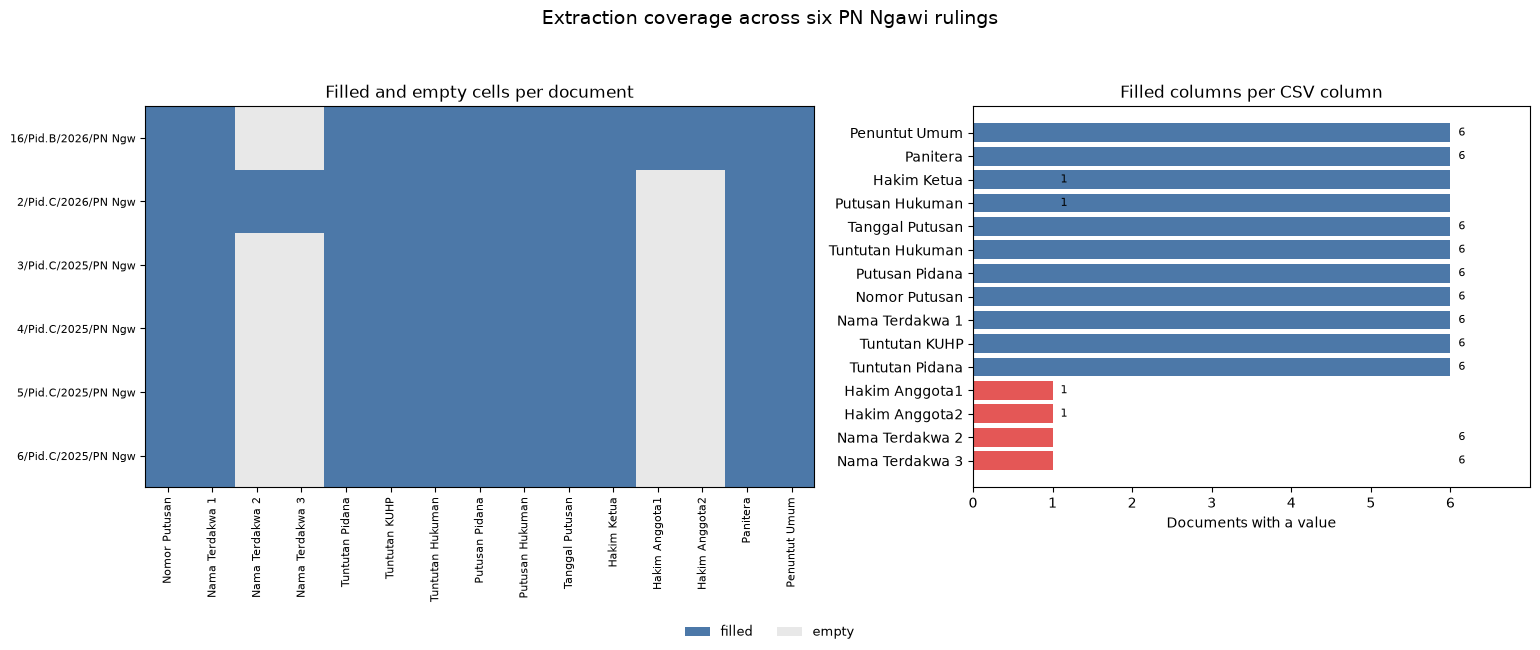

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ACCENT, MUTED, WARN = "#4C78A8", "#E8E8E8", "#E45756"
present = (df != "").to_numpy()
counts = present.sum(axis=0)

fig, (ax_grid, ax_bar) = plt.subplots(
    1, 2, figsize=(15.5, 6.5), gridspec_kw={"width_ratios": [1.2, 1]})
fig.suptitle("Extraction coverage across six PN Ngawi rulings", fontsize=14)

ax_grid.imshow(present.astype(float), aspect="auto",
               cmap=ListedColormap([MUTED, ACCENT]), vmin=0, vmax=1)
ax_grid.set_xticks(range(len(COLUMNS)))
ax_grid.set_xticklabels(COLUMNS, rotation=90, fontsize=8)
ax_grid.set_yticks(range(len(df)))
ax_grid.set_yticklabels(df["Nomor Putusan"], fontsize=8)
ax_grid.set_title("Filled and empty cells per document")

order = np.argsort(counts)
ax_bar.barh([COLUMNS[i] for i in order], counts[order],
            color=[WARN if counts[i] <= 1 else ACCENT for i in order])
ax_bar.set_xlim(0, len(df) + 1)
ax_bar.set_xticks(range(len(df) + 1))
ax_bar.set_xlabel("Documents with a value")
ax_bar.set_title("Filled columns per CSV column")
for row, value in zip(order, counts[order]):
    ax_bar.text(value + 0.1, row, str(value), va="center", fontsize=8)

fig.legend(handles=[Patch(facecolor=ACCENT, label="filled"),
                    Patch(facecolor=MUTED, label="empty")],
           loc="lower center", ncol=2, frameon=False, fontsize=9)
fig.tight_layout(rect=[0, 0.045, 1, 0.94])
plt.show()

Pembersihan teks di atas baru diukur pada satu berkas. Diagram berikut
mengukur keenam berkas sekaligus memakai fungsi yang sama, sehingga jumlah
karakter yang tersisa dapat dibandingkan antar dokumen.

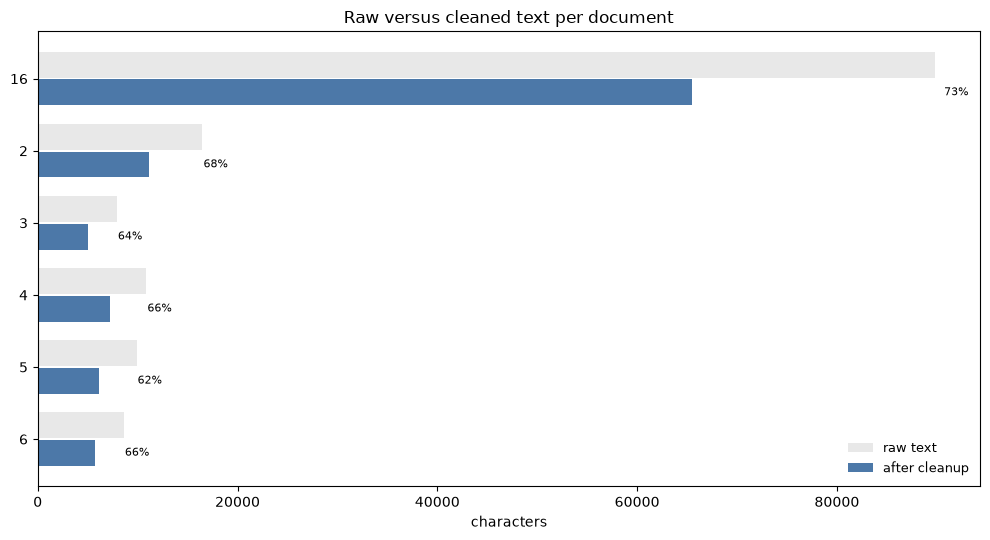

In [23]:
doc_ids = [number.split("/")[0] for number in df["Nomor Putusan"]]
raw_chars, clean_chars = [], []
for pdf in pdfs:
    pages = pdf_pages(pdf)
    raw_chars.append(sum(len(page) for page in pages))
    clean_chars.append(len(body_text(pages)))

rows_axis = range(len(pdfs))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh([y - 0.19 for y in rows_axis], raw_chars, height=0.36, color=MUTED, label="raw text")
ax.barh([y + 0.19 for y in rows_axis], clean_chars, height=0.36, color=ACCENT, label="after cleanup")
ax.set_yticks(list(rows_axis))
ax.set_yticklabels(doc_ids)
ax.invert_yaxis()
ax.set_xlabel("characters")
ax.set_title("Raw versus cleaned text per document")
for y, (raw, clean) in enumerate(zip(raw_chars, clean_chars)):
    ax.text(raw * 1.01, y + 0.19, f"{clean / raw:.0%}", va="center", fontsize=8)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

Isi enam putusan diringkas dua cara. Panel kiri menampilkan jenis tindak
pidana, panel kanan menampilkan vonis dalam urutan lama hukuman. Satu nilai
tindak pidana panjangnya sekitar 250 karakter, jadi dipotong pada label agar
tetap terbaca, sedangkan teks penuhnya ada pada keluaran B.4. Angka pada
kedua panel diambil dari kolom hasil ekstraksi, sehingga sekaligus memeriksa
keluaran aturan dari luar.

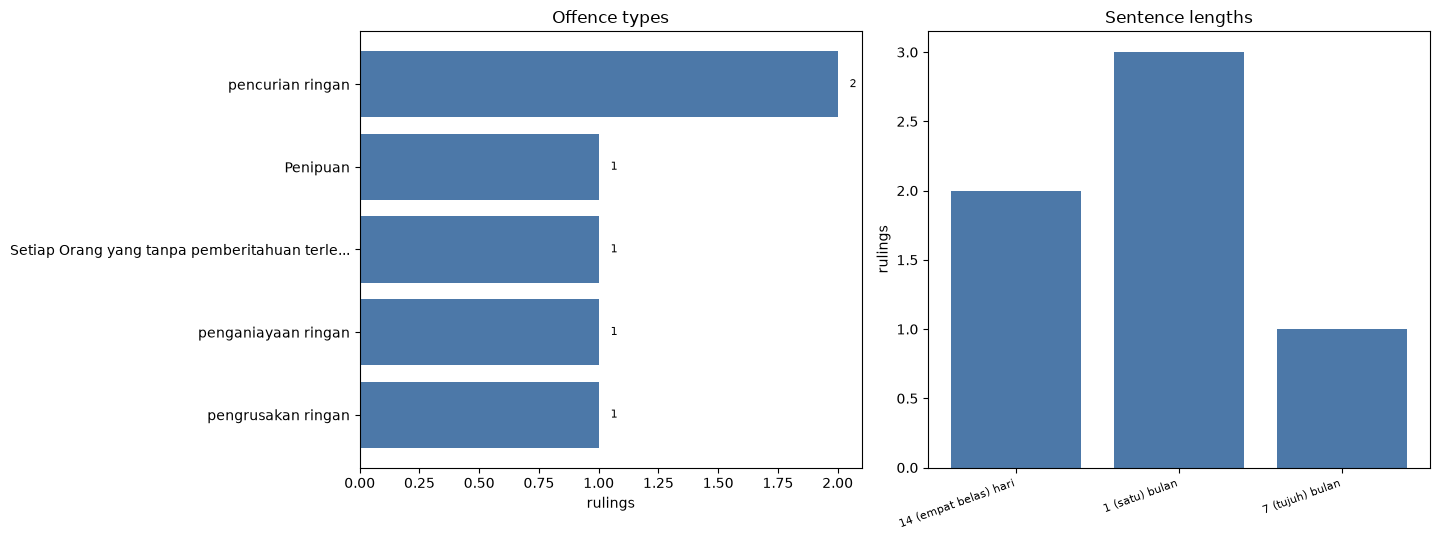

In [24]:
def shorten(label, width=46):
    return label if len(label) <= width else label[: width - 3] + "..."


def sentence_days(label):
    number = int(re.match(r"(\d+)", label).group(1))
    return number * 30 if "bulan" in label else number


offence_counts = df["Tuntutan Pidana"].value_counts()
sentence_counts = df["Putusan Hukuman"].value_counts()
sentence_order = sorted(sentence_counts.index, key=sentence_days)

fig, (ax_offence, ax_sentence) = plt.subplots(1, 2, figsize=(14.5, 5.5))

ax_offence.barh([shorten(v) for v in offence_counts.index],
                offence_counts.values, color=ACCENT)
ax_offence.invert_yaxis()
ax_offence.set_xlabel("rulings")
ax_offence.set_title("Offence types")
for row, value in enumerate(offence_counts.values):
    ax_offence.text(value + 0.05, row, str(value), va="center", fontsize=8)

ax_sentence.bar(sentence_order, [sentence_counts[s] for s in sentence_order], color=ACCENT)
ax_sentence.set_ylabel("rulings")
ax_sentence.set_title("Sentence lengths")
plt.setp(ax_sentence.get_xticklabels(), rotation=20, ha="right", fontsize=8)

fig.tight_layout()
plt.show()

## B.5 Results PDF

Tugas ini dikumpulkan dalam dua berkas PDF. `IE-RuleBased-230411100197.pdf` berisi
notebook ini lengkap dengan seluruh output yang sudah dijalankan, termasuk
catatan pada setiap aturan. `IE-RuleBased-Hasil-230411100197.pdf` berisi
hasil ekstraksi saja, yaitu tabel CSV beserta rincian nilai tiap entitas
pada keenam dokumen. Berkedua nama berkas mengikuti format `NIM` yang
diminta soal.

Hasil PDF dibuat dari notebook yang sama, sehingga angka yang tampil di
kedua berkas tidak mungkin berbeda dengan output pada B.4.

## C. Assessment

Ada tiga keterbatasan yang perlu diketahui. Pertama, `Tuntutan Pidana`
dan `Tuntutan Hukuman` tidak dapat dibedakan dari `Putusan` pada format PN
Ngawi karena dokumennya hanya punya satu blok vonis. Kedua, tiga dokumen
hanya menyebut instansi penuntut umum sehingga kolom `Penuntut Umum` berisi
keterangan instansi, bukan nama pribadi. Ketiga, kolom `Nama Terdakwa` hanya
menampung tiga nama pertama, sehingga ketujuh terdakwa pada
`2/Pid.C/2026/PN Ngw` tidak ikut terbawa.

In [25]:
for txt in sorted(TXT_DIR.glob("*.txt")):
    print(f"{txt.name:32} {txt.stat().st_size:7} byte")
print()
print(f"{OUT_CSV.name}  {OUT_CSV.stat().st_size} bytes, {len(df)} rows, {len(df.columns)} columns")

16-Pid.B-2026-PN-Ngawi.txt         89923 byte
2-Pid.C-2026-PN-Ngawi.txt          16450 byte
3-Pid.C-2025-PN-Ngawi.txt           7965 byte
4-Pid.C-2025-PN-Ngawi.txt          10892 byte
5-Pid.C-2025-PN-Ngawi.txt           9916 byte
6-Pid.C-2025-PN-Ngawi.txt           8657 byte

courtHistory-PN-Ngawi.csv  2200 bytes, 6 rows, 15 columns
